## Part 1: Quick ML Workflow

Since today's focus is **evaluation**, we will keep preprocessing and model training minimal and fast — just enough to generate `y_pred` so we can evaluate it properly.

### About the Dataset
The **Abalone dataset** is used to predict the **age of an abalone (a sea snail)** from physical measurements. Age is estimated as `Rings + 1.5` (years).

Since Logistic Regression is a **classification** algorithm, we will convert this into a classification problem:

> **Task:** Predict whether an abalone is **"Old"** (age > 10 years) or **"Young"** (age ≤ 10 years) based on its physical measurements.

This gives us a clean **binary classification** problem — perfect for a 2×2 Confusion Matrix.


In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, accuracy_score,
                              precision_score, recall_score, f1_score)

# Cleaner plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Step 2: Load the Abalone Dataset
df = pd.read_csv("abalone.csv")
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


### Step 3: Basic EDA (Exploratory Data Analysis)

Before touching the model, we always inspect the data first.

In [3]:
# Shape of the dataset -> (rows, columns)
print("Shape of dataset:", df.shape)

Shape of dataset: (4177, 9)


In [4]:
# Info -> column names, data types, non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB


In [5]:
# Statistical summary of numeric columns
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [6]:
# Check for missing values in each column
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

In [7]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Observation:** The Abalone dataset is generally clean — no missing values and very few (if any) duplicates. This is why we can keep preprocessing minimal today.

### Step 4: Minimal Preprocessing

Two small steps are needed:
1. **Encode the `Sex` column** — it is categorical (`M`, `F`, `I`) and Logistic Regression needs numbers.
2. **Create our target column** — convert `Rings` into a binary label: `Old` (1) vs `Young` (0).

If any missing values existed, we would handle them here too (e.g., using `.fillna()` with mean/median).

In [8]:
# Handle missing values if any existed (none here, but shown for completeness)
df = df.dropna()  # safe no-op since dataset has no missing values

# Encode the categorical column 'Sex' (M, F, I -> 0, 1, 2)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
print("Sex categories mapped as:", dict(zip(le.classes_, le.transform(le.classes_))))

# Create the binary target: Age = Rings + 1.5
df['Age'] = df['Rings'] + 1.5
df['AgeGroup'] = np.where(df['Age'] > 10, 1, 0)   # 1 = Old, 0 = Young

df[['Rings', 'Age', 'AgeGroup']].head()

Sex categories mapped as: {'F': np.int64(0), 'I': np.int64(1), 'M': np.int64(2)}


,Rings,Age,AgeGroup
0,15,16.5,1
1,7,8.5,0
2,9,10.5,1
3,10,11.5,1
4,7,8.5,0


In [9]:
# Check class balance of our target
df['AgeGroup'].value_counts()

AgeGroup
1    2770
0    1407
Name: count, dtype: int64

### Step 5: Feature Selection

We use the physical measurement columns as features (`X`) and `AgeGroup` as the target (`y`). We drop `Rings` and `Age` from the features since they were used to *create* the target (using them would leak the answer into the model).

In [10]:
# Feature selection
X = df.drop(columns=['Rings', 'Age', 'AgeGroup'])
y = df['AgeGroup']

print("Features used:", list(X.columns))
print("Target:", 'AgeGroup (1 = Old, 0 = Young)')

Features used: ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']
Target: AgeGroup (1 = Old, 0 = Young)


### Step 6: Train-Test Split

We split the data so we can train on one portion and test on unseen data — this is essential for honest evaluation.

In [11]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling helps Logistic Regression converge better
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3341
Testing samples: 836


### Step 7: Train a Logistic Regression Classifier

In [12]:
# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model training complete!")

Model training complete!


### Step 8: Make Predictions

This `y_pred` is what we will evaluate for the rest of the session.

In [13]:
# Predict on the test set
y_pred = model.predict(X_test_scaled)

print("Sample Actual   :", list(y_test[:10]))
print("Sample Predicted:", list(y_pred[:10]))

Sample Actual   : [1, 1, 0, 1, 1, 0, 1, 1, 0, 1]
Sample Predicted: [np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1)]


---
# Part 2: Confusion Matrix (Main Focus)

## What is a Confusion Matrix?

A **Confusion Matrix** is a table that compares the model's **predicted labels** against the **actual (true) labels**. It shows exactly *where* the model got things right and *where* it got "confused."

## Why is it used?

- A single number like "accuracy" can **hide** important problems (e.g., a model can be 95% accurate but still fail badly on the minority class).
- The confusion matrix breaks predictions down into **four specific categories**, letting us see the *type* of mistake the model makes — not just *how many* mistakes.
- It is the foundation used to calculate almost every other classification metric (Accuracy, Precision, Recall, F1-Score).

## Structure of a 2×2 Confusion Matrix

For binary classification (Old = 1, Young = 0):

```
                        Predicted: Young (0)   Predicted: Old (1)
Actual: Young (0)             TN                     FP
Actual: Old (1)                FN                     TP
```

| Term | Meaning |
|---|---|
| **True Positive (TP)**  | Model predicted **Old**, and it actually **was Old**. ✅ Correct |
| **True Negative (TN)**  | Model predicted **Young**, and it actually **was Young**. ✅ Correct |
| **False Positive (FP)** | Model predicted **Old**, but it was actually **Young**. ❌ Wrong (also called a "Type I Error") |
| **False Negative (FN)** | Model predicted **Young**, but it was actually **Old**. ❌ Wrong (also called a "Type II Error") |

**Memory trick:** The *second word* (Positive/Negative) is what the model **predicted**. The *first word* (True/False) tells you whether that prediction was **correct**.


In [14]:
# Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[184  98]
 [ 53 501]]


### Visualizing the Confusion Matrix with `seaborn.heatmap()`

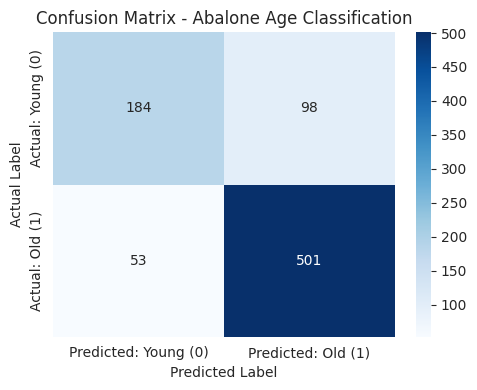

In [15]:
# Visualize using seaborn heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Young (0)', 'Predicted: Old (1)'],
            yticklabels=['Actual: Young (0)', 'Actual: Old (1)'])
plt.title('Confusion Matrix - Abalone Age Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### Extracting TP, TN, FP, FN using `.ravel()`

`.ravel()` flattens the 2×2 matrix into a 1D array in the order: **TN, FP, FN, TP**.

In [16]:
# Extract TN, FP, FN, TP
TN, FP, FN, TP = cm.ravel()

print(f"True Negative  (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"True Positive  (TP): {TP}")

True Negative  (TN): 184
False Positive (FP): 98
False Negative (FN): 53
True Positive  (TP): 501


---
## Deriving Metrics from the Confusion Matrix

### 1. Accuracy
**"Out of all predictions, how many were correct?"**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

- **Use case:** Good when classes are **balanced** (roughly equal Young/Old counts).
- **Limitation:** Misleading with **imbalanced** data. Example: if 95% of patients don't have a disease, predicting "no disease" for everyone gives 95% accuracy — but the model is useless for finding sick patients.

### 2. Precision
**"Out of everything the model predicted as Positive (Old), how many were actually Old?"**

$$Precision = \frac{TP}{TP + FP}$$

- **Focus:** Quality of positive predictions — minimizing **False Positives**.
- **Real-world example:** Spam email detection. A False Positive means a genuine, important email gets sent to spam — costly! We want **high precision** here.

### 3. Recall (a.k.a. Sensitivity / True Positive Rate)
**"Out of all the actual Positives (Old), how many did the model correctly catch?"**

$$Recall = \frac{TP}{TP + FN}$$

- **Focus:** Coverage of actual positives — minimizing **False Negatives**.
- **Real-world example:** Cancer/disease detection. A False Negative means a sick patient is told they are healthy — dangerous! We want **high recall** here.

### 4. F1-Score
**"A single score that balances Precision and Recall."**

$$F1\text{-}Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

- It is the **harmonic mean** of Precision and Recall (harmonic mean punishes extreme imbalance between the two more than a simple average would).
- **Use case:** Best when you need a **balance** between Precision and Recall, especially with **imbalanced classes**.


In [17]:
# Calculate metrics manually from TP, TN, FP, FN
accuracy_manual  = (TP + TN) / (TP + TN + FP + FN)
precision_manual = TP / (TP + FP)
recall_manual    = TP / (TP + FN)
f1_manual        = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)

print(f"Accuracy  (manual): {accuracy_manual:.4f}")
print(f"Precision (manual): {precision_manual:.4f}")
print(f"Recall    (manual): {recall_manual:.4f}")
print(f"F1-Score  (manual): {f1_manual:.4f}")

Accuracy  (manual): 0.8194
Precision (manual): 0.8364
Recall    (manual): 0.9043
F1-Score  (manual): 0.8690


In [18]:
# Verify using sklearn's built-in functions
print(f"Accuracy  (sklearn): {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (sklearn): {precision_score(y_test, y_pred):.4f}")
print(f"Recall    (sklearn): {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  (sklearn): {f1_score(y_test, y_pred):.4f}")

Accuracy  (sklearn): 0.8194
Precision (sklearn): 0.8364
Recall    (sklearn): 0.9043
F1-Score  (sklearn): 0.8690

Notice: manual calculations match sklearn's output exactly!


---
# Part 3: Classification Report

`classification_report()` gives us **Precision, Recall, F1-Score, and Support** for **every class**, plus overall averages — all in one readable table.

In [19]:
# Generate the classification report
report = classification_report(y_test, y_pred, target_names=['Young (0)', 'Old (1)'])
print(report)

              precision    recall  f1-score   support

   Young (0)       0.78      0.65      0.71       282
     Old (1)       0.84      0.90      0.87       554

    accuracy                           0.82       836
   macro avg       0.81      0.78      0.79       836
weighted avg       0.82      0.82      0.82       836



### Understanding Each Column

| Column | Meaning |
|---|---|
| **Precision** | Of everything predicted as this class, what fraction was correct? (calculated separately per class) |
| **Recall** | Of all actual members of this class, what fraction did the model correctly find? |
| **F1-Score** | Harmonic mean of Precision and Recall for that class. |
| **Support** | The **actual number of true samples** of that class in the test set (not a performance metric — just a count, used to judge how much to "trust" the other metrics). |

### Macro Average
$$Macro\ Avg = \frac{\text{metric for class 0} + \text{metric for class 1}}{\text{number of classes}}$$

- Simple, **unweighted** average across classes.
- Treats every class **equally important**, regardless of how many samples it has.
- **Use when:** You care equally about performance on *every* class, even rare ones (e.g., detecting a rare disease is just as important as detecting a common one).

### Weighted Average
$$Weighted\ Avg = \sum_{i} \left(\frac{\text{support}_i}{\text{total samples}} \times \text{metric}_i\right)$$

- Averages the metrics **weighted by Support** (class size).
- Larger classes influence the final score more.
- **Use when:** You care about **overall performance** on the dataset as it naturally occurs (i.e., class imbalance is expected and acceptable).

### Quick Rule of Thumb
- **Balanced classes** → Accuracy and Macro Average are reliable.
- **Imbalanced classes** → Prefer Weighted Average, or look closely at Precision/Recall/F1 for the minority class specifically.


---
# Part 4: Practice

## Manual Calculation Example

Suppose a model was tested on 100 emails to detect spam, and produced this confusion matrix:

```
                     Predicted: Not Spam   Predicted: Spam
Actual: Not Spam            50                   10
Actual: Spam                  5                   35
```

Here: **TN = 50, FP = 10, FN = 5, TP = 35**

**Step-by-step calculation:**

1. **Accuracy** = (TP + TN) / Total = (35 + 50) / 100 = **0.85 (85%)**
2. **Precision** = TP / (TP + FP) = 35 / (35 + 10) = **0.777 (77.8%)**
3. **Recall** = TP / (TP + FN) = 35 / (35 + 5) = **0.875 (87.5%)**
4. **F1-Score** = 2 × (0.778 × 0.875) / (0.778 + 0.875) = **0.824 (82.4%)**

**Interpretation:** The model catches most spam (high recall) but occasionally flags real emails as spam too (precision is a bit lower than recall).


In [20]:
# Try it yourself: verify the manual example above using code
TN_ex, FP_ex, FN_ex, TP_ex = 50, 10, 5, 35

acc_ex  = (TP_ex + TN_ex) / (TP_ex + TN_ex + FP_ex + FN_ex)
prec_ex = TP_ex / (TP_ex + FP_ex)
rec_ex  = TP_ex / (TP_ex + FN_ex)
f1_ex   = 2 * (prec_ex * rec_ex) / (prec_ex + rec_ex)

print(f"Accuracy:  {acc_ex:.3f}")
print(f"Precision: {prec_ex:.3f}")
print(f"Recall:    {rec_ex:.3f}")
print(f"F1-Score:  {f1_ex:.3f}")

Accuracy:  0.850
Precision: 0.778
Recall:    0.875
F1-Score:  0.824


## Practice Questions

1. A model has TP = 40, TN = 30, FP = 20, FN = 10. Calculate its Accuracy, Precision, Recall, and F1-Score.
2. In a medical test for a serious disease, would you prioritize **Precision** or **Recall**? Justify your answer.
3. A classifier achieves 98% accuracy on a dataset where 97% of samples belong to one class. Is this model actually good? Explain why or why not.
4. Using the Abalone confusion matrix generated above, identify how many "Old" abalones were incorrectly classified as "Young." Which metric does this error affect the most?
5. When would you prefer the **Macro Average** over the **Weighted Average** in a classification report? Give a real-world example.


## Interview Questions

1. What is the difference between Type I Error and Type II Error, and how do they relate to False Positive and False Negative?
2. Why can accuracy be a misleading metric? Give a real-world scenario where high accuracy does not mean a good model.
3. Explain the difference between Precision and Recall in your own words, using a real-world example for each.
4. Why is F1-Score the harmonic mean (not the simple average) of Precision and Recall? What does this achieve?
5. If you had to choose only ONE metric to evaluate a model for detecting fraudulent transactions, which would you choose and why?


---
## Summary — What We Learned Today

- Built a quick Logistic Regression model on the Abalone dataset to generate predictions for evaluation.
- **Confusion Matrix**: a 2×2 table of TP, TN, FP, FN that shows *exactly* how a model is right or wrong.
- **Accuracy, Precision, Recall, F1-Score**: all derived directly from the confusion matrix, each answering a different question.
- **Classification Report**: a complete summary table with per-class metrics plus Macro and Weighted averages.
- The "best" metric always depends on the **problem** — there is no single metric that works for every situation.
